In [1]:
import numpy as np 

import matplotlib.pyplot as plt

from delta_sigma_simulator.modulator import DeltaSigmaModulator
from delta_sigma_simulator.filter import FilterIntegrator, FilterFirstOrder, FilterSecondOrder
from delta_sigma_simulator.quantizer import QuantizerDelayHysteresis
from delta_sigma_simulator.wave import BinaryWave

In [2]:
beta_sim = np.logspace(0, 3, 20) 
beta = np.logspace(0, 3, 1000)

f0 = 1

In [3]:
f0_sim = np.zeros_like(beta_sim)
f2_sim = np.zeros_like(beta_sim)

V1_sim = np.zeros_like(beta_sim)
V3_sim = np.zeros_like(beta_sim)

for i, beta_i in enumerate(beta_sim):
    loop_filter = FilterIntegrator(2 * np.pi * f0 / beta_i)
    quantizer = QuantizerDelayHysteresis(0, np.pi / 2 / beta_i)
    quantizer.t_step = 0.1
    asdm = DeltaSigmaModulator(loop_filter, quantizer)

    U = np.linspace(-0.01, 0.01, 51)
    f_sim = np.zeros_like(U)
    V_sim = np.zeros_like(U)

    for j, U_j in enumerate(U):
        v = asdm.simulate([BinaryWave(E=U_j)], n=10)

        assert np.isclose(v.e[-1] - v.e[-3], v.e[-3] - v.e[-5]), "Simulation failed to converge."
            
        f_sim[j] = 1 / (v.e[-1] - v.e[-3])
        V_sim[j] = -v.E * (-1 + 2 * (v.e[-2] - v.e[-3]) / (v.e[-1] - v.e[-3]))

    res = np.polynomial.polynomial.polyfit(V_sim, f_sim, 7)

    f0_sim[i] = f_sim[len(f_sim) // 2]
    f2_sim[i] = res[2]
    
    res = np.polynomial.polynomial.polyfit(U, V_sim, 7)

    V1_sim[i] = res[1]
    V3_sim[i] = res[3]

In [4]:
f2 = -1 * np.ones_like(beta)

V1 = 1 * np.ones_like(beta)
V3 = 0 * np.ones_like(beta)

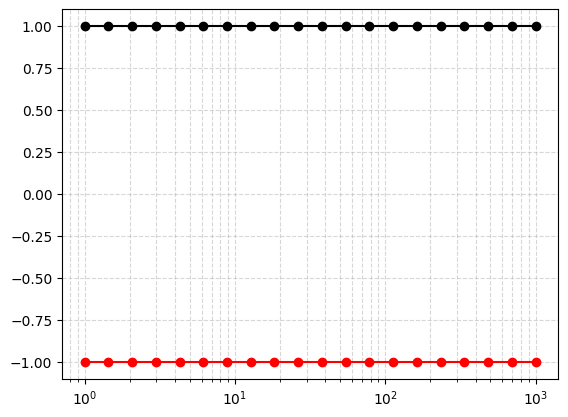

In [5]:
plt.semilogx(beta_sim, f0_sim, 'ko')
plt.semilogx(beta, f0 * np.ones_like(beta), 'k-')

plt.semilogx(beta_sim, f2_sim / f0_sim, 'ro')
plt.semilogx(beta, f2 / f0, 'r-')

plt.grid(which="both", ls="--", alpha=0.5)
plt.show()

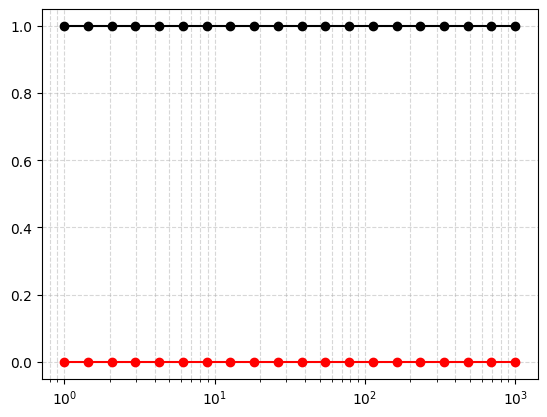

In [6]:
plt.semilogx(beta_sim, V1_sim, 'ko')
plt.semilogx(beta, V1, 'k-')

plt.semilogx(beta_sim, V3_sim, 'ro')
plt.semilogx(beta, V3, 'r-')

plt.grid(which="both", ls="--", alpha=0.5)
plt.show()

In [7]:
np.savetxt("asdm-loop-filter-integrator-simulation.csv", np.column_stack((beta_sim, f0_sim, f2_sim, V1_sim, V3_sim)), delimiter=",")
np.savetxt("asdm-loop-filter-integrator-expression.csv", np.column_stack((beta, f0 * np.ones_like(beta), f2, V1, V3)), delimiter=",")

In [8]:
f0_sim = np.zeros_like(beta_sim)
f2_sim = np.zeros_like(beta_sim)

V1_sim = np.zeros_like(beta_sim)
V3_sim = np.zeros_like(beta_sim)

for i, beta_i in enumerate(beta_sim):
    loop_filter = FilterFirstOrder(f0 / beta_i)
    quantizer = QuantizerDelayHysteresis(0, np.tanh(np.pi / 2 / beta_i))
    quantizer.t_step = 0.1
    asdm = DeltaSigmaModulator(loop_filter, quantizer)

    U = np.linspace(-0.01, 0.01, 51)
    f_sim = np.zeros_like(U)
    V_sim = np.zeros_like(U)

    for j, U_j in enumerate(U):
        v = asdm.simulate([BinaryWave(E=U_j)], n=10)

        assert np.isclose(v.e[-1] - v.e[-3], v.e[-3] - v.e[-5]), "Simulation failed to converge."
            
        f_sim[j] = 1 / (v.e[-1] - v.e[-3])
        V_sim[j] = -v.E * (-1 + 2 * (v.e[-2] - v.e[-3]) / (v.e[-1] - v.e[-3]))

    res = np.polynomial.polynomial.polyfit(V_sim, f_sim, 7)

    f0_sim[i] = f_sim[len(f_sim) // 2]
    f2_sim[i] = res[2]
    
    res = np.polynomial.polynomial.polyfit(U, V_sim, 7)

    V1_sim[i] = res[1]
    V3_sim[i] = res[3]

In [9]:
f2 = -np.pi / (2 * beta) / np.tanh(np.pi / 2 / beta)

V1 = np.sinh(np.pi / beta) / (np.pi / beta)
V3 = np.pi ** 2 / 6 / beta ** 2 * (3 / 2 / np.tanh(np.pi / 2 / beta) ** 2 - 3 * beta / np.pi / np.tanh(np.pi / 2 / beta) + 1 / 2) * V1 ** 3

alpha = np.abs(1 + 1j * f0 / (f0 / beta))

V1_2 = 1 / (1 - np.pi ** 2 / alpha / beta)
V3_2 = np.pi ** 2 / 6 / alpha / beta / (1 - np.pi ** 2 / 6 / alpha / beta) ** 3

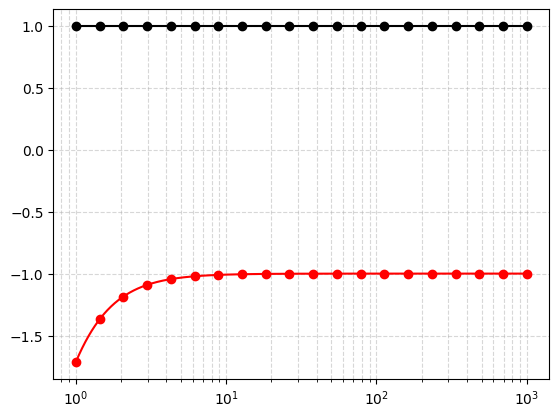

In [10]:
plt.semilogx(beta_sim, f0_sim, 'ko')
plt.semilogx(beta, f0 * np.ones_like(beta), 'k-')

plt.semilogx(beta_sim, f2_sim / f0_sim, 'ro')
plt.semilogx(beta, f2 / f0, 'r-')

plt.grid(which="both", ls="--", alpha=0.5)
plt.show()

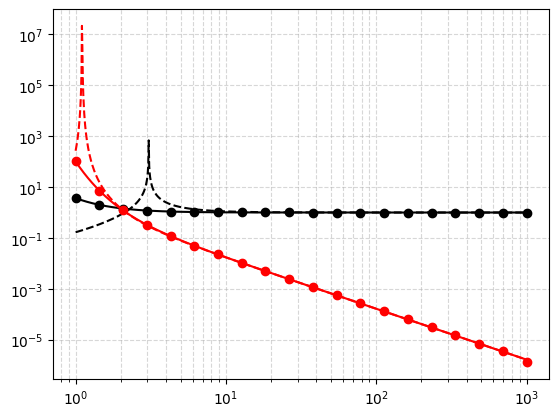

In [11]:
plt.loglog(beta_sim, np.abs(V1_sim), 'ko')
plt.loglog(beta, np.abs(V1), 'k-')
plt.loglog(beta, np.abs(V1_2), 'k--')

plt.loglog(beta_sim, np.abs(V3_sim), 'ro')
plt.loglog(beta, np.abs(V3), 'r-')
plt.loglog(beta, np.abs(V3_2), 'r--')

plt.grid(which="both", ls="--", alpha=0.5)
plt.show()

In [12]:
np.savetxt("asdm-loop-filter-low-pass-simulation.csv", np.column_stack((beta_sim, f0_sim, f2_sim, V1_sim, V3_sim)), delimiter=",")
np.savetxt("asdm-loop-filter-low-pass-expression.csv", np.column_stack((beta, f0 * np.ones_like(beta), f2, V1, V3, V1_2, V3_2)), delimiter=",")

In [ ]:
beta_sim = np.logspace(1, 3, 10)

f0_sim = np.zeros_like(beta_sim)
f2_sim = np.zeros_like(beta_sim)

V1_sim = np.zeros_like(beta_sim)
V3_sim = np.zeros_like(beta_sim)

loop_filter = FilterSecondOrder(1e-1, 1e-2, 1e-3)

fg = 1e-1 - 1e-2 - 1e-3

for i, beta_i in enumerate(beta_sim):
    f0 = fg * beta_i

    quantizer = QuantizerDelayHysteresis(0, np.pi / 2 * np.abs(loop_filter.frequency_response(2 * np.pi * f0)))
    quantizer.t_step = 1 / (10 * f0)
    asdm = DeltaSigmaModulator(loop_filter, quantizer)

    U = np.linspace(-0.01, 0.01, 51)
    f_sim = np.zeros_like(U)
    V_sim = np.zeros_like(U)

    for j, U_j in enumerate(U):
        v = asdm.simulate([BinaryWave(E=U_j)], n=50)

        assert np.isclose(v.e[-1] - v.e[-3], v.e[-3] - v.e[-5]), "Simulation failed to converge."
            
        f_sim[j] = 1 / (v.e[-1] - v.e[-3])
        V_sim[j] = -v.E * (-1 + 2 * (v.e[-2] - v.e[-3]) / (v.e[-1] - v.e[-3]))

        print(f"beta: {beta_i:.2f}, U: {U_j:.4f}, f: {f_sim[j]:.4f}, V: {V_sim[j]:.4f}")

    res = np.polynomial.polynomial.polyfit(V_sim, f_sim, 7)

    f0_sim[i] = f_sim[len(f_sim) // 2]
    f2_sim[i] = res[2]
    
    res = np.polynomial.polynomial.polyfit(U, V_sim, 7)

    V1_sim[i] = res[1]
    V3_sim[i] = res[3]


beta: 10.00, U: -0.0100, f: 0.8853, V: -0.0100
beta: 10.00, U: -0.0096, f: 0.8853, V: -0.0096
beta: 10.00, U: -0.0092, f: 0.8853, V: -0.0092
beta: 10.00, U: -0.0088, f: 0.8853, V: -0.0088
beta: 10.00, U: -0.0084, f: 0.8853, V: -0.0084
beta: 10.00, U: -0.0080, f: 0.8854, V: -0.0080
beta: 10.00, U: -0.0076, f: 0.8854, V: -0.0076
beta: 10.00, U: -0.0072, f: 0.8854, V: -0.0072
beta: 10.00, U: -0.0068, f: 0.8854, V: -0.0068
beta: 10.00, U: -0.0064, f: 0.8854, V: -0.0064
beta: 10.00, U: -0.0060, f: 0.8854, V: -0.0060
beta: 10.00, U: -0.0056, f: 0.8854, V: -0.0056
beta: 10.00, U: -0.0052, f: 0.8854, V: -0.0052
beta: 10.00, U: -0.0048, f: 0.8854, V: -0.0048
beta: 10.00, U: -0.0044, f: 0.8854, V: -0.0044
beta: 10.00, U: -0.0040, f: 0.8854, V: -0.0040
beta: 10.00, U: -0.0036, f: 0.8854, V: -0.0036
beta: 10.00, U: -0.0032, f: 0.8854, V: -0.0032
beta: 10.00, U: -0.0028, f: 0.8854, V: -0.0028
beta: 10.00, U: -0.0024, f: 0.8854, V: -0.0024
beta: 10.00, U: -0.0020, f: 0.8854, V: -0.0020
beta: 10.00, 

In [ ]:
U = np.linspace(-0.1, 0.1, 101)
f_sim = np.zeros_like(U)
V_sim = np.zeros_like(U)

for j, U_j in enumerate(U):
    v = asdm.simulate([BinaryWave(E=U_j)], n=50)

    assert np.isclose(v.e[-1] - v.e[-3], v.e[-3] - v.e[-5]), "Simulation failed to converge."
        
    f_sim[j] = 1 / (v.e[-1] - v.e[-3])
    V_sim[j] = -v.E * (-1 + 2 * (v.e[-2] - v.e[-3]) / (v.e[-1] - v.e[-3]))

    print(f"beta: {beta_i:.2f}, U: {U_j:.4f}, f: {f_sim[j]:.4f}, V: {V_sim[j]:.4f}")

beta: 1000.00, U: -0.1000, f: 88.1100, V: -0.1000
beta: 1000.00, U: -0.0980, f: 88.1452, V: -0.0980
beta: 1000.00, U: -0.0960, f: 88.1797, V: -0.0960
beta: 1000.00, U: -0.0940, f: 88.2136, V: -0.0940
beta: 1000.00, U: -0.0920, f: 88.2467, V: -0.0920
beta: 1000.00, U: -0.0900, f: 88.2791, V: -0.0900
beta: 1000.00, U: -0.0880, f: 88.3108, V: -0.0880
beta: 1000.00, U: -0.0860, f: 88.3417, V: -0.0860
beta: 1000.00, U: -0.0840, f: 88.3720, V: -0.0840
beta: 1000.00, U: -0.0820, f: 88.4015, V: -0.0820
beta: 1000.00, U: -0.0800, f: 88.4304, V: -0.0800
beta: 1000.00, U: -0.0780, f: 88.4585, V: -0.0780
beta: 1000.00, U: -0.0760, f: 88.4859, V: -0.0760
beta: 1000.00, U: -0.0740, f: 88.5126, V: -0.0740
beta: 1000.00, U: -0.0720, f: 88.5386, V: -0.0720
beta: 1000.00, U: -0.0700, f: 88.5639, V: -0.0700
beta: 1000.00, U: -0.0680, f: 88.5884, V: -0.0680
beta: 1000.00, U: -0.0660, f: 88.6123, V: -0.0660
beta: 1000.00, U: -0.0640, f: 88.6354, V: -0.0640
beta: 1000.00, U: -0.0620, f: 88.6579, V: -0.0620


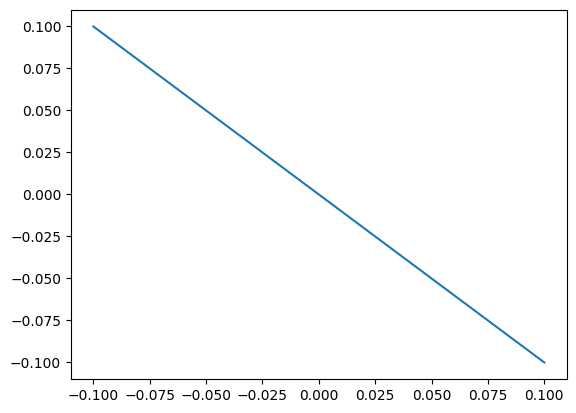

In [89]:
plt.plot(U, V_sim)

res = np.polynomial.polynomial.polyfit(U, V_sim, 3)

In [90]:
res[3]

np.float64(-1.1051854169927345e-06)

In [ ]:
f2 = -1 * beta * fg

alpha = np.abs(loop_filter.frequency_response(0) / loop_filter.frequency_response(2 * np.pi * fg * beta))

V1 = 1 / (1 + np.pi ** 2 / alpha / beta)
V3 = -np.pi ** 2 / 6 / alpha / beta / (1 + np.pi ** 2 / 6 / alpha / beta) ** 3

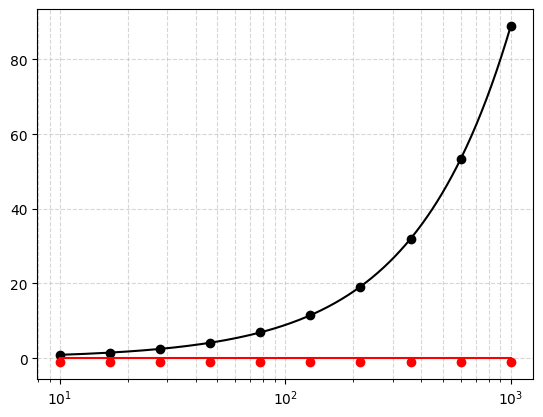

In [70]:
beta = np.logspace(1, 3, 1000)

plt.semilogx(beta_sim, f0_sim, 'ko')
plt.semilogx(beta, fg * beta, 'k-')

plt.semilogx(beta_sim, f2_sim / f0_sim, 'ro')
plt.semilogx(beta, f2 / f0, 'r-')

plt.grid(which="both", ls="--", alpha=0.5)
plt.show()

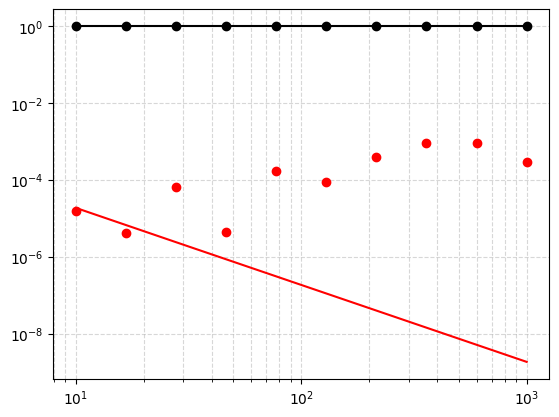

In [71]:
plt.loglog(beta_sim, np.abs(V1_sim), 'ko')
plt.loglog(beta, np.abs(V1), 'k-')

plt.loglog(beta_sim, np.abs(V3_sim), 'ro')
plt.loglog(beta, np.abs(V3), 'r-')

plt.grid(which="both", ls="--", alpha=0.5)
plt.show()

In [ ]:
np.savetxt("asdm-loop-filter-general-simulation.csv", np.column_stack((beta_sim, f0_sim, f2_sim, V1_sim, V3_sim)), delimiter=",")
np.savetxt("asdm-loop-filter-general-expression.csv", np.column_stack((beta, beta * fg, f2, V1, V3)), delimiter=",")